In [2]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
from IPython.display import Image, display

In [ ]:
# OpenAI gpt model as llm
llm=ChatOpenAI(model="gpt-5-mini", temperature=1.0)

In [ ]:
# Python class to store states
class GraphState (TypedDict):
    transcript: str
    topics_list: list[str]
    meeting_summary: str
    task_assignees: list[tuple[str, str]]
    task_priorities: list[tuple[str, str]]
    final_report: str

    

In [ ]:
# input node to read input transcript
def input_node(state: GraphState) -> GraphState:
    state['transcript'] = input_transcript
    return state

In [32]:
# Topic extraction node
def extract_topics(state: GraphState) -> GraphState:
    transcript = state['transcript']
    topics = llm.invoke(f"""Extract the main topics from the meeting transcript. Max 3 topics. 
    Topics are separated by new lines. 
    
    Input is transcript. 
    
    Return value is string.
    
    Transcript:\n\n{transcript}""")
    #print(f'extract_topics. topics:{topics}')
    #print(type(topics))
    state['topics_list'] = topics.content.split('\n')  # Assuming topics are separated by newlines
    return state

In [33]:
# Meeting summarization node
def summarize_meeting(state: GraphState) -> GraphState:
    transcript = state['transcript']
    summary = llm.invoke(f"""Summarize the following meeting transcript in a concise manner. Summarize in
    3-4 sentences. 
    
    Input is transcript. 
    
    Return value is string.

    Transcript:\n\n{transcript}""")
    state['meeting_summary'] = summary.content
    return state

In [34]:
# Action items extraction node
def extract_action_items(state: GraphState) -> GraphState:
    transcript = state['transcript']
    action_items = llm.invoke(f"""Extract the action items from the meeting transcript. An action item consists
    of a task and an assignee. Format the output as a list of tupples with first element 'task' and 
    second element 'assignee'. If no assignee found for a task, assign 'Not Specified'. If no action items found, 
    return empty list.
    
    Input is transcript. 
    
    Return value is a list of tuples.

    Transcript:\n\n{transcript}""")
    
    state['task_assignees'] = action_items.content
    return state

In [35]:
# Task Priority extraction node
def extract_task_priorities(state: GraphState) -> GraphState:
    transcript = state['transcript']
    task_priorities = llm.invoke(f"""Extract the task priorities from the meeting transcript. A task priority 
    consists of a task and its priority level (High, Medium, Low). Format the output as a list of tupples 
    with first element 'task' and second element 'priority'. If no priority found for a task, assign 
    'Not Specified'. Inputs are transcript and task_assignees which is a list of tuples. 
    Return value is a list of tuples.
    Transcript:\n\n{transcript}""")
    
    state['task_priorities'] = task_priorities.content
    return state

In [36]:
# Report generation node
def generate_report(state: GraphState) -> GraphState:
    meeting_summary = state['meeting_summary']
    task_assignees = state['task_assignees']
    task_priorities = state['task_priorities']
    topics_list = state['topics_list']
    
    report = llm.invoke(f"""Generate a comprehensive report based on the meeting summary, action items, topics
    list and task priorities. 
    The report should include the meeting summary followed by topics list and then list of action items 
    with their respective assignees and priority levels. 
    
    Input is meeting_summary, task_assignees, topics_list and task_priorities. Return value is a string.
    Meeting Summary:\n\n{meeting_summary}\n\nAction Items:\n\n{task_assignees}\n\nTask Priorities:\n\n{task_priorities}""")
    
    state['final_report'] = report.content
    return state

In [ ]:
# router node for conditional routing.
def router_node(state: GraphState) -> GraphState:
    #print(f'router_node. state:{state}')
    #return {'task_assignees': state['task_assignees']} 
    return state

In [ ]:
# routing function. This function will be used by the router node to decide which route to take.
def routing_function(state: GraphState) -> str:
    task_assignees = state['task_assignees']
    if task_assignees:
        return 'branch_extract_task_priorities'
    return 'branch_generate_report'

In [ ]:
# Defining workflows
workflow=StateGraph(GraphState)
workflow.add_node('input_node',input_node)
workflow.add_node('extract_topics',extract_topics)
workflow.add_node('summarize_meeting',summarize_meeting)
workflow.add_node('extract_action_items',extract_action_items)
workflow.add_node('router_node',router_node)
workflow.add_node('extract_task_priorities',extract_task_priorities)
workflow.add_node('generate_report',generate_report)

workflow.add_edge(START, 'input_node')
workflow.add_edge('input_node', 'extract_topics')
workflow.add_edge('extract_topics', 'summarize_meeting')
workflow.add_edge('summarize_meeting', 'extract_action_items')
workflow.add_edge('extract_action_items', 'router_node')
workflow.add_conditional_edges(
"router_node",
routing_function,
    {
        "branch_extract_task_priorities": "extract_task_priorities",
        "branch_generate_report": "generate_report"
    }
)

workflow.add_edge('extract_task_priorities', 'generate_report')
workflow.add_edge('generate_report', END)

app=workflow.compile()

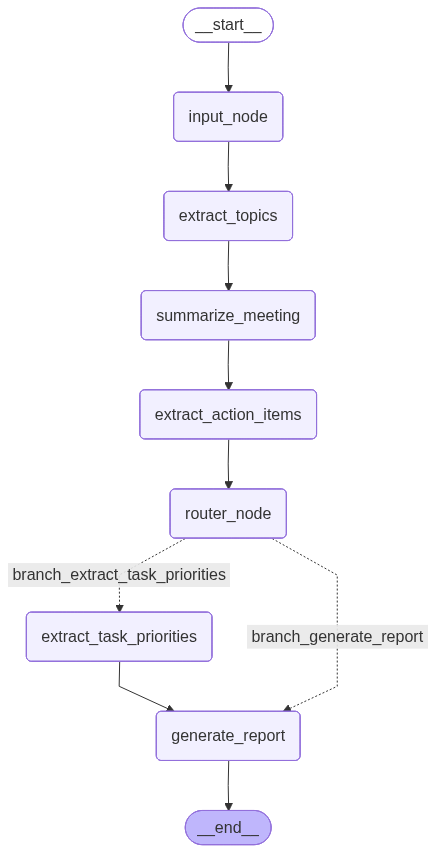

In [15]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# Input transcript.
input_transcript = """

Product Manager: Good morning everyone. We have received several complaints about the mobile app crashing during login.

Customer Support Lead: Yes, our support team received more than 120 complaints in the last two days.

Product Manager: That is quite serious. We need to identify the root cause quickly.

Mobile Developer: I checked some of the crash logs yesterday and noticed that most of the issues are coming from Android users.

QA Tester: I also tried reproducing the issue on an Android device and the app crashed right after entering login credentials.

Backend Developer: Could the issue be related to the authentication API?

Mobile Developer: That is possible. The login request might be failing due to some recent backend changes.

Product Manager: When was the last update deployed to production?

Backend Developer: We deployed a small update to the authentication service three days ago.

QA Tester: The crash reports also started appearing around the same time.

Mobile Developer: I suspect the issue might be related to how the mobile app handles the API response.

Backend Developer: Let me check whether the API response format has changed.

Product Manager: Good idea. We need to investigate both the mobile and backend components.

Customer Support Lead: Customers are getting frustrated because they cannot access their accounts.

Product Manager: Yes, we must resolve this issue urgently.

Mobile Developer: I will review the Android login module and check if any error handling is missing.

QA Tester: I will prepare a detailed bug report with screenshots and logs.

Backend Developer: I will verify the authentication API and check if there are any breaking changes.

Product Manager: Please prioritize this issue today.

QA Tester: Should we also test the app on different Android versions?

Mobile Developer: Yes, that would help identify if the issue is device specific.

QA Tester: I will test the login flow on Android 11, 12, and 13.

Backend Developer: I will also check the server logs to see if any authentication errors are recorded.

Product Manager: Good. Let's also inform the management team about this issue.

Customer Support Lead: I will send a message to the support team so they can update customers that we are working on a fix.

Mobile Developer: If the issue is in the login module, I should be able to push a fix by tomorrow.

QA Tester: Once the fix is ready, I will perform regression testing.

Backend Developer: I will also test the authentication endpoints after the fix is deployed.

Product Manager: Great. Please document the issue and the resolution steps.

QA Tester: I will update the issue tracker with all findings.

Customer Support Lead: Should we also prepare a communication message for users?

Product Manager: Yes, we should notify users once the fix is deployed.

Mobile Developer: I will also add better error handling so the app does not crash even if the API fails.

Backend Developer: That would definitely improve stability.

QA Tester: After testing, we should release the patch update to the Play Store.

Product Manager: Yes, but only after we confirm that the issue is fully resolved.

Mobile Developer: I will start working on the fix immediately after this meeting.

Backend Developer: I will review the API logs right away.

QA Tester: I will share the bug report within the next hour.

Product Manager: Thank you everyone for the quick response.

Customer Support Lead: Hopefully we can resolve this before more users are affected.

Mobile Developer: I will provide an update by the end of the day.

Backend Developer: Same here. I will report any issues I find.

Product Manager: Let's regroup tomorrow morning to review the progress.

QA Tester: Sounds good.

Customer Support Lead: Thank you everyone.

Product Manager: Meeting adjourned.

"""

In [20]:
print(f'llm={llm.model_name}')

llm=gpt-5-mini


In [ ]:
# Invoking workflow graph using gpt model and displaying final report.
state=app.invoke({'transcript': input_transcript})
print(state['final_report'])

Meeting Summary:
The team addressed an urgent issue where the mobile app has been crashing during login for many users (120+ complaints) since an authentication service update three days ago, with crashes occurring mainly on Android. Developers suspect a changed API response or missing error handling in the Android login module. Backend will review logs and API; mobile dev will implement fixes and improve error handling; QA will reproduce and test on Android 11–13 and prepare a bug report. Customer Support will inform users and management. The team aims to release a patched Play Store update after regression testing and will regroup tomorrow to review progress.

Topics List:
- Issue overview and impact (120+ crash reports; Android-focused)
- Suspected causes (changed API response; missing error handling in Android login module)
- Immediate developer actions (mobile fixes, backend log/API review)
- QA plan (reproduce on Android 11–13, bug report, regression testing)
- Backend verificati

In [72]:
display(state)

{'transcript': "\n\nProduct Manager: Good morning everyone. We have received several complaints about the mobile app crashing during login.\n\nCustomer Support Lead: Yes, our support team received more than 120 complaints in the last two days.\n\nProduct Manager: That is quite serious. We need to identify the root cause quickly.\n\nMobile Developer: I checked some of the crash logs yesterday and noticed that most of the issues are coming from Android users.\n\nQA Tester: I also tried reproducing the issue on an Android device and the app crashed right after entering login credentials.\n\nBackend Developer: Could the issue be related to the authentication API?\n\nMobile Developer: That is possible. The login request might be failing due to some recent backend changes.\n\nProduct Manager: When was the last update deployed to production?\n\nBackend Developer: We deployed a small update to the authentication service three days ago.\n\nQA Tester: The crash reports also started appearing aro

In [ ]:
# Using gemini
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
# Setting gemini as llm.
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=1.0)

In [40]:
print(f'llm={llm}')

llm=model='models/gemini-2.0-flash-lite' google_api_key=SecretStr('**********') temperature=1.0 client=<google.ai.generativelanguage_v1beta.services.generative_service.client.GenerativeServiceClient object at 0x0000016B41AB07A0> default_metadata=()


In [ ]:
# Invoking workflow graph using gemini model and displaying final report.
state=app.invoke({'transcript': input_transcript})
print(state['final_report'])

**Meeting Report: Mobile App Login Crashing Issue**

**Meeting Summary:**

The team convened to address a critical issue causing the mobile application to crash during the login process, predominantly affecting Android users. This instability is believed to be a direct consequence of a recent backend update to the authentication service, deployed approximately three days prior. Current efforts are focused on a dual investigation of both the mobile login module and the authentication API to pinpoint the root cause. The primary objective is to implement an urgent fix to mitigate customer frustration and prevent further impact. A patch update will be released following comprehensive testing, and relevant stakeholders, including management and users, will be kept informed of the resolution.

---

**Topics Discussed:**

*   **Mobile App Crashing During Login:** The central issue being addressed, impacting Android users.
*   **Backend Authentication Service Update:** The suspected trigger fo